<a href="https://colab.research.google.com/github/ChaeHaKyung/D4D-DEFENSE-TECH-HACKTHON/blob/main/XView3_FirstPlace_Incheon_Inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 인천 VH/VV TIFF — xView3 1위 CircleNet 앙상블 추론
공식 저장소: https://github.com/BloodAxe/xView3-The-First-Place-Solution
검토한 소스 commit: 9a9600e7dfbaa24ff5a72c81061fbbbfed865847

**Colab GPU 런타임에서 VH/VV를 /content에 올린 뒤 순서대로 실행하세요.** 수심, 라벨, 기존 SARFish model.pth는 사용하지 않습니다.

공식 release 1.0 `traced_ensemble.jit`를 사용합니다(1,304,877,218 bytes, 모델 12개+좌우 TTA). .jit 파일을 직접 업로드해도 됩니다. 1.3GB 다운로드와 앙상블 추론은 자원 소모가 큽니다. 원본 README의 24GB 조건은 tracing 검증 조건이며 이 코드는 tracing을 수행하지 않습니다. 그래도 작은 GPU에서 추론 메모리가 부족할 수 있습니다. OOM이면 상위 GPU에서 실행하거나 별도 단일 모델 경로가 필요합니다.

VH/VV dB를 같은 UTM52N 10m 격자로 맞추고 **VH → VV 순서**, sigmoid((dB+20)*0.18) 정규화를 사용합니다. Lee/CLAHE 및 수심은 사용하지 않습니다. 입력이 선형 power이면 SAR_UNITS='power'로 명시하세요.

원본은 2048 타일/1536 step의 pyramid 가중 병합을 사용합니다. 이 버전은 같은 크기와 step의 **균등 평균 병합**으로 의존성을 줄였습니다. 따라서 공식 대회 파이프라인과 완전히 동일한 재현은 아닙니다. CenterNet stride2 중심/offset/길이 디코딩 및 기본 threshold(0.3/0.338/0.35)는 공식 설정을 따릅니다. 인천에서 최적 threshold/성능은 별도 검증이 필요합니다.

이 노트북의 전처리·타일 병합·디코딩은 합성 데이터로 검증했습니다. 공식 1.3GB JIT를 이 환경에서 다운로드해 실제 추론한 것은 아닙니다. Colab에서 로딩 및 출력 형상을 검사합니다.


In [ ]:
%pip -q install rasterio scipy pandas matplotlib requests tqdm
import json, math, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.warp import calculate_default_transform, transform as transform_coords
from rasterio.enums import Resampling
import requests
from tqdm.auto import tqdm
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
assert DEVICE.type=='cuda', '런타임 유형을 GPU로 변경하세요. 12모델 앙상블은 CPU에서 매우 느립니다.'
print('GPU:',torch.cuda.get_device_name(0),'torch:',torch.__version__)


GPU: Tesla T4 torch: 2.11.0+cu130


In [ ]:
VH_PATH=Path('/content/VH.tif')
VV_PATH=Path('/content/VV.tif')
VH_BAND=1
VV_BAND=1
SAR_UNITS='db'  # 'power'는 선형 power 데이터일 때만 사용
TARGET_CRS='EPSG:32652'
RESOLUTION_M=10
MODEL_PATH=Path('/content/xview3_firstplace_traced_ensemble.jit')
DOWNLOAD_MODEL=True  # 공식 .jit를 직접 올렸다면 False도 가능
MODEL_URL='https://github.com/BloodAxe/xView3-The-First-Place-Solution/releases/download/1.0/traced_ensemble.jit'
MODEL_EXPECTED_BYTES=1304877218
TILE=2048
STEP=1536
OUTPUT_STRIDE=2
OBJECTNESS_THRESHOLD=0.300
VESSEL_THRESHOLD=0.338
FISHING_THRESHOLD=0.350
MAX_OBJECTS=2048
USE_FP16=True
MAX_SCENE_PIXELS=40_000_000  # CPU의 전체 영상/출력 맵 저장 메모리 제한
PREVIEW_MAX_SIDE=1800
OUTPUT_ROOT=Path('/content/firstplace_results')
assert SAR_UNITS in {'db','power'}
assert TILE==2048 and STEP==1536, '공식 traced 모델은 기본 입력 크기로 실행하세요.'
for p in [VH_PATH,VV_PATH]: assert p.is_file(), f'파일 없음: {p}'
from datetime import datetime
OUTPUT_DIR=OUTPUT_ROOT/datetime.now().strftime('%Y%m%d_%H%M%S_%f')
OUTPUT_DIR.mkdir(parents=True,exist_ok=False)


## 1. 공식 가중치 다운로드 및 손상 확인
이어받기 파일은 .part로 유지합니다. 완성된 파일의 크기와 ZIP 디렉토리를 확인한 뒤 사용합니다.

In [ ]:
def download_official_jit():
    if MODEL_PATH.is_file():
        if MODEL_PATH.stat().st_size!=MODEL_EXPECTED_BYTES or not zipfile.is_zipfile(MODEL_PATH):
            raise ValueError('기존 .jit 파일 크기/ZIP 형식이 다릅니다. 파일을 확인한 뒤 정상 공식 파일로 교체하세요.')
        return
    assert DOWNLOAD_MODEL, f'공식 .jit를 업로드하세요: {MODEL_PATH}'
    MODEL_PATH.parent.mkdir(parents=True,exist_ok=True)
    partial=MODEL_PATH.with_suffix('.jit.part')
    offset=partial.stat().st_size if partial.exists() else 0
    if offset>MODEL_EXPECTED_BYTES: raise ValueError('.part가 예상 크기보다 큽니다. 확인 후 삭제하세요.')
    if offset<MODEL_EXPECTED_BYTES:
        headers={'Accept-Encoding':'identity'}
        if offset: headers['Range']=f'bytes={offset}-'
        with requests.get(MODEL_URL,headers=headers,stream=True,timeout=(30,120)) as response:
            response.raise_for_status()
            append=response.status_code==206 and offset>0
            if response.status_code==206:
                expected=offset if append else 0
                assert response.headers.get('Content-Range','').startswith(f'bytes {expected}-'), '이어받기 위치 오류'
            if not append: offset=0
            with partial.open('ab' if append else 'wb') as file,tqdm(total=MODEL_EXPECTED_BYTES,
                initial=offset,unit='B',unit_scale=True,desc='공식 모델') as bar:
                for chunk in response.iter_content(1024*1024):
                    if chunk: file.write(chunk);bar.update(len(chunk))
    if partial.stat().st_size!=MODEL_EXPECTED_BYTES or not zipfile.is_zipfile(partial):
        raise ValueError('모델 다운로드가 불완전합니다. 셀을 다시 실행해 이어받거나 공식 파일을 직접 업로드하세요.')
    partial.replace(MODEL_PATH)

download_official_jit()
model=torch.jit.load(str(MODEL_PATH),map_location='cpu').eval().to(DEVICE)
print('공식 JIT 로딩 완료:',MODEL_PATH)


공식 모델:   0%|          | 0.00/1.30G [00:00<?, ?B/s]

공식 JIT 로딩 완료: /content/xview3_firstplace_traced_ensemble.jit


## 2. VH/VV 정합과 sigmoid 정규화
원본 TIFF를 변경하지 않습니다. 해상도를 10m로 바꿔도 원래 정보 해상도가 높아지는 것은 아닙니다.

In [ ]:
def normalize_sar(values,valid,units='db'):
    db=values.astype(np.float32,copy=True)
    if units=='power':
        valid=valid & (db>0)
        db=10*np.log10(np.maximum(db,1e-12))
    result=torch.sigmoid(torch.from_numpy((db+20.0)*0.18)).numpy()
    result[~valid]=0
    return result.astype(np.float32),valid

def load_sar_scene():
    with rasterio.open(VH_PATH) as src:
        assert src.crs, 'VH 좌표계 없음'
        transform,width,height=calculate_default_transform(src.crs,TARGET_CRS,
            src.width,src.height,*src.bounds,resolution=RESOLUTION_M)
    assert width*height<=MAX_SCENE_PIXELS, '장면이 메모리 제한보다 큽니다. 영역을 나누거나 MAX_SCENE_PIXELS를 여유 RAM에 맞춰 지정하세요.'
    crs=rasterio.crs.CRS.from_user_input(TARGET_CRS)
    assert crs.is_projected and crs.linear_units in {'metre','meter'} and RESOLUTION_M==10
    image=[];valid=np.ones((height,width),bool)
    for p,band in [(VH_PATH,VH_BAND),(VV_PATH,VV_BAND)]:
        with rasterio.open(p) as src:
            assert src.crs and 1<=band<=src.count
            with WarpedVRT(src,crs=crs,transform=transform,width=width,height=height,
                resampling=Resampling.bilinear,nodata=-32768,dtype='float32') as vrt:
                a=vrt.read(band,masked=True)
                values=a.astype(np.float32).filled(-32768)
                ok=~np.ma.getmaskarray(a)&np.isfinite(values)&(values>-30000)
                normalized,ok=normalize_sar(values,ok,SAR_UNITS)
                image.append(normalized);valid &= ok
    image=np.stack(image);image[:,~valid]=0
    assert valid.any(), '유효 VH/VV 영역이 없습니다.'
    return image,valid,transform,crs

image,valid,scene_transform,scene_crs=load_sar_scene()
height,width=valid.shape
print('정합 영상:',image.shape,scene_crs,'유효 비율:',f'{valid.mean():.1%}')


정합 영상: (2, 1828, 1995) EPSG:32652 유효 비율: 94.9%


## 3. 겹치는 창의 출력 맵 병합
공식 앙상블 출력은 이미 확률이므로 sigmoid를 다시 적용하지 않습니다. 출력 맵은 CPU에서 병합해 GPU 메모리 사용을 줄입니다.

In [ ]:
OBJ='CENTERNET_OUTPUT_OBJECTNESS_MAP'
VESSEL='CENTERNET_OUTPUT_VESSEL_MAP'
FISHING='CENTERNET_OUTPUT_FISHING_MAP'
SIZE='CENTERNET_OUTPUT_SIZE'
OFFSET='CENTERNET_OUTPUT_OFFSET'

# 경계 포함 격자; 영상이 타일보다 작으면 한 번만 추론
rows=[i*STEP for i in range(max(1,math.ceil((height-TILE)/STEP)+1))]
cols=[i*STEP for i in range(max(1,math.ceil((width-TILE)/STEP)+1))]
padded_h,padded_w=rows[-1]+TILE,cols[-1]+TILE
map_h,map_w=padded_h//2,padded_w//2
maps={key:np.zeros((channels,map_h,map_w),np.float32)
      for key,channels in [(OBJ,1),(VESSEL,1),(FISHING,1),(SIZE,1),(OFFSET,2)]}
weights=np.zeros((map_h,map_w),np.float32)
with torch.inference_mode():
    for row,col in tqdm([(r,c) for r in rows for c in cols],desc='1위 앙상블 추론'):
        hh,ww=min(TILE,height-row),min(TILE,width-col)
        if hh<=0 or ww<=0 or not valid[row:row+hh,col:col+ww].any(): continue
        tile=np.zeros((2,TILE,TILE),np.float32);tile[:,:hh,:ww]=image[:,row:row+hh,col:col+ww]
        tensor=torch.from_numpy(tile[None]).to(DEVICE)
        try:
            with torch.autocast(device_type='cuda',dtype=torch.float16,enabled=USE_FP16):
                output=model(tensor)
        except torch.cuda.OutOfMemoryError as error:
            raise RuntimeError('공식 12모델 앙상블 추론에서 GPU 메모리가 부족합니다. 상위 GPU 또는 별도의 단일 모델 추론을 사용하세요.') from error
        assert isinstance(output,dict), f'예상과 다른 JIT 출력: {type(output)}'
        assert set(maps)<=set(output), f'예상 출력 맵 없음: {list(output)}'
        y,x=row//2,col//2;s=TILE//2
        for key in maps:
            a=output[key].detach().float().cpu().numpy()
            assert a.shape==(1,maps[key].shape[0],s,s), f'{key}: 출력 형상 {a.shape}; 공식 JIT/입력 크기 확인'
            if key in [OBJ,VESSEL,FISHING]:
                assert np.nanmin(a)>=-1e-4 and np.nanmax(a)<=1.0001, '공식 확률 출력이 아닙니다. 다른 모델을 넣지 마세요.'
            maps[key][:,y:y+s,x:x+s]+=np.nan_to_num(a[0],nan=0,posinf=0,neginf=0)
        weights[y:y+s,x:x+s]+=1
        del output,tensor
for key in maps:
    maps[key]=np.divide(maps[key],weights[None],out=np.zeros_like(maps[key]),where=weights[None]>0)
    maps[key]=maps[key][:,:math.ceil(height/2),:math.ceil(width/2)]
del weights


1위 앙상블 추론:   0%|          | 0/1 [00:00<?, ?it/s]

## 4. CenterNet 중심 디코딩과 결과 저장
이 모델은 실제 박스가 아닌 중심점과 길이를 예측합니다. 표시 이미지는 중심점입니다. 길이/어업 여부는 모델 추정값입니다.

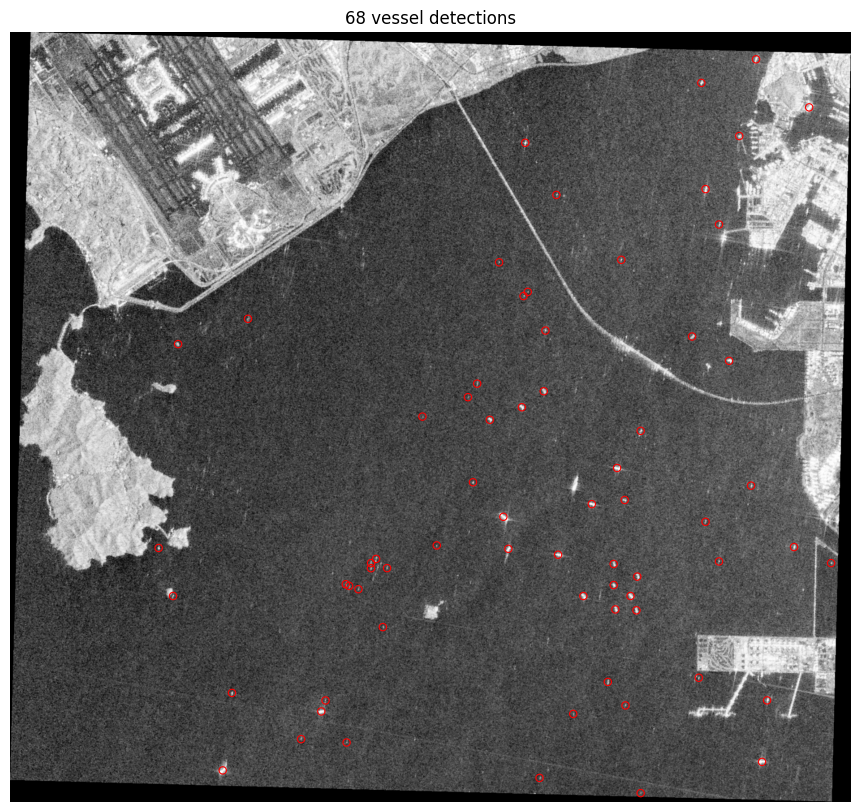

배 탐지: 68 결과: /content/firstplace_results/20261010_135929_109374


,detect_scene_row,detect_scene_column,objectness_p,is_vessel_p,is_fishing_p,is_vessel,is_fishing,vessel_length_m,lon,lat,source_vh
0,1068.396484,1098.364014,0.714803,0.803977,0.059044,True,False,30.064096,126.521811,37.386295,/content/VH.tif
1,1612.458008,738.311035,0.698060,0.908304,0.031944,True,False,85.395470,126.482815,37.336444,/content/VH.tif
2,120.288086,1640.374756,0.687879,0.498000,0.051488,True,False,40.152668,126.580234,37.472946,/content/VH.tif
3,1568.455078,526.344971,0.671251,0.783839,0.128406,True,False,29.789185,126.458776,37.339895,/content/VH.tif
4,1542.340332,1418.371826,0.650826,0.533150,0.105850,True,False,30.580479,126.559310,37.344365,/content/VH.tif
5,1120.309082,1380.365234,0.650510,0.834275,0.029971,True,False,83.018967,126.553789,37.382285,/content/VH.tif
6,1222.242798,1860.376953,0.629338,0.461794,0.040819,True,False,35.122704,126.608254,37.374212,/content/VH.tif
7,1240.406250,1300.276855,0.629144,0.746709,0.034560,True,False,83.660645,126.545104,37.371282,/content/VH.tif
8,540.302734,1450.352295,0.620429,0.711372,0.203397,True,False,26.684071,126.559993,37.434680,/content/VH.tif
9,1338.345703,1472.331055,0.614302,0.781437,0.029263,True,False,61.666496,126.564803,37.362862,/content/VH.tif


/content/firstplace_results/20261010_135929_109374/detections.csv

In [ ]:
def decode_maps(maps,valid,max_objects,obj_threshold,vessel_threshold,fishing_threshold):
    obj=torch.from_numpy(maps[OBJ][None]).float()
    pooled=F.max_pool2d(obj,kernel_size=3,stride=1,padding=1)
    peaks=obj*(pooled==obj)
    scores,indices=torch.topk(peaks.flatten(),k=min(max_objects,peaks.numel()))
    mw=obj.shape[-1];ys=indices//mw;xs=indices%mw
    offset=torch.from_numpy(maps[OFFSET])
    cx=(xs.float()+offset[0,ys,xs])*2
    cy=(ys.float()+offset[1,ys,xs])*2
    vessel=torch.from_numpy(maps[VESSEL][0])[ys,xs]
    fishing=torch.from_numpy(maps[FISHING][0])[ys,xs]
    log_length=torch.from_numpy(maps[SIZE][0])[ys,xs]
    lengths=(torch.exp(F.relu(log_length))-1)*10  # 원본 log2length + decode_lengths
    keep=(scores>=obj_threshold)&(vessel>=vessel_threshold)
    keep &= (cx>=0)&(cx<valid.shape[1])&(cy>=0)&(cy<valid.shape[0])
    ids=torch.where(keep)[0]
    if len(ids):
        ix=cx[ids].floor().long().numpy();iy=cy[ids].floor().long().numpy()
        keep[ids] &= torch.from_numpy(valid[iy,ix])
    return pd.DataFrame({'detect_scene_row':cy[keep].numpy(),'detect_scene_column':cx[keep].numpy(),
        'objectness_p':scores[keep].numpy(),'is_vessel_p':vessel[keep].numpy(),
        'is_fishing_p':fishing[keep].numpy(),'is_vessel':np.ones(int(keep.sum()),bool),
        'is_fishing':(fishing[keep]>=fishing_threshold).numpy(),'vessel_length_m':lengths[keep].numpy()})

detections=decode_maps(maps,valid,MAX_OBJECTS,OBJECTNESS_THRESHOLD,VESSEL_THRESHOLD,FISHING_THRESHOLD)
if len(detections):
    gx,gy=scene_transform*(detections.detect_scene_column.to_numpy()+.5,detections.detect_scene_row.to_numpy()+.5)
    lon,lat=transform_coords(scene_crs,'EPSG:4326',gx.tolist(),gy.tolist())
    detections['lon']=lon;detections['lat']=lat
else:
    detections['lon']=pd.Series(dtype=float);detections['lat']=pd.Series(dtype=float)
detections['source_vh']=str(VH_PATH)
detections.to_csv(OUTPUT_DIR/'detections.csv',index=False)
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
scale=min(1.,PREVIEW_MAX_SIDE/max(height,width))
preview=zoom(image.mean(0),scale,order=1)
fig,ax=plt.subplots(figsize=(13,10));ax.imshow(preview,cmap='gray',vmin=0,vmax=1)
if len(detections):
    ax.scatter(detections.detect_scene_column*(preview.shape[1]/width),
        detections.detect_scene_row*(preview.shape[0]/height),s=28,facecolors='none',edgecolors='red',linewidths=.8)
ax.set_title(f'{len(detections)} vessel detections');ax.axis('off')
fig.savefig(OUTPUT_DIR/'detections_overview.png',dpi=150,bbox_inches='tight');plt.show();plt.close(fig)
settings={'repository_commit':'9a9600e7dfbaa24ff5a72c81061fbbbfed865847','model_url':MODEL_URL,
 'vh':str(VH_PATH),'vv':str(VV_PATH),'sar_units':SAR_UNITS,'channels':['vh','vv'],
 'crs':str(scene_crs),'transform':list(scene_transform)[:6],'height':height,'width':width,
 'normalization':{'midpoint':-20,'temperature':.18},'tile':TILE,'step':STEP,'merge':'uniform',
 'objectness_threshold':OBJECTNESS_THRESHOLD,'vessel_threshold':VESSEL_THRESHOLD,'fishing_threshold':FISHING_THRESHOLD}
(OUTPUT_DIR/'inference_settings.json').write_text(json.dumps(settings,ensure_ascii=False,indent=2))
print('배 탐지:',len(detections),'결과:',OUTPUT_DIR)
display(detections.head(20))
from IPython.display import FileLink
display(FileLink(str(OUTPUT_DIR/'detections.csv')))


## 라이선스
정규화/디코딩은 원본 구현을 바탕으로 적용했습니다. 모델 사용에는 원본 배포 조건이 적용됩니다.
```text
MIT License

Copyright (c) 2021 Eugene Khvedchenya

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.

```
